In [ ]:
%pip install -q numpy==2.4.4 pandas==3.0.2 scikit-learn==1.8.0 joblib==1.5.3 matplotlib==3.10.8 seaborn==0.13.2

# 01 - Exploratory Data Analysis
(EDA)
Khám phá dữ liệu đoán đột quỵ: kích thước, missing values, mất cân bằng nhãn và các phân phối quan trọng.

In [ ]:
from pathlib import Path
from zipfile import ZipFile
from importlib import import_module
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_NAME = 'healthcare-dataset-stroke-data.csv'
SEARCH_ROOTS = [Path.cwd(), *Path.cwd().parents]
DATA_ROOTS = []
for root in SEARCH_ROOTS:
    DATA_ROOTS.extend([root / 'ai-models' / 'data', root / 'data'])
zip_candidates = [root / 'dataset.zip' for root in DATA_ROOTS]
zip_path = next((path for path in zip_candidates if path.exists()), None)

if zip_path is None:
    try:
        files = import_module('google.colab.files')
    except ImportError as error:
        raise FileNotFoundError('Khong tim thay dataset.zip. Dat file vao ai-models/data/ hoac upload tren Colab.') from error
    uploaded = files.upload()
    uploaded_path = Path('/content') / next(iter(uploaded))
    if uploaded_path.name != 'dataset.zip':
        raise ValueError('Vui long upload dung file dataset.zip.')
    zip_path = uploaded_path

with ZipFile(zip_path) as archive:
    csv_names = [name for name in archive.namelist() if Path(name).name == DATA_NAME]
    if not csv_names:
        raise FileNotFoundError(f'{DATA_NAME} khong co trong {zip_path}')
    with archive.open(csv_names[0]) as csv_file:
        df = pd.read_csv(csv_file)

print(f'ZIP input: {zip_path}')
print(f'CSV trong ZIP: {csv_names[0]}')
print(f'Shape: {df.shape}')
df.head()

Note: you may need to restart the kernel to use updated packages.
ZIP input: c:\Users\Admin\Desktop\17_12523101_10123337_DuDoanDotQuy.git\ai-models\data\dataset.zip
CSV trong ZIP: healthcare-dataset-stroke-data.csv
Shape: (5110, 12)



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1007,Male,47.94,0,0,Yes,children,Urban,114.82,19.4,smokes,0
1,1014,Female,61.34,1,1,Yes,Private,Rural,147.37,20.6,smokes,0
2,1021,Female,43.21,0,0,Yes,Private,Rural,129.49,10.0,never smoked,0
3,1028,Female,39.59,0,1,No,Govt_job,Urban,117.73,31.7,never smoked,0
4,1035,Male,65.64,0,0,Yes,children,Urban,55.00,32.3,never smoked,0


In [12]:
print('Kieu du lieu va kich thuoc:')
display(df.dtypes.to_frame('dtype'))
print(f'Trung lap: {df.duplicated().sum()} dong')
display(df.describe(include='all').T)
missing = df.isna().sum().sort_values(ascending=False)
print('Gia tri thieu:')
display(missing[missing > 0].to_frame('missing_rows'))
print('Target distribution:')
display(df['stroke'].value_counts().to_frame('count'))
display((df['stroke'].value_counts(normalize=True) * 100).round(2).to_frame('percent'))

Kieu du lieu va kich thuoc:


,dtype
id,int64
gender,str
age,float64
hypertension,int64
heart_disease,int64
ever_married,str
work_type,str
Residence_type,str
avg_glucose_level,float64
bmi,float64


Trung lap: 0 dong


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,18888.5,10326.919878,1007.0,9947.75,18888.5,27829.25,36770.0
gender,5110,3,Female,3013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.170022,21.374741,1.95,26.2125,40.255,58.5075,82.0
hypertension,5110.0,NaN,NaN,NaN,0.236204,0.42479,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.189432,0.39189,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Rural,2592,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,112.876247,39.414926,55.0,81.9025,109.89,138.8175,268.42
bmi,4910.0,NaN,NaN,NaN,28.505275,7.494288,10.0,23.4,28.5,33.6,54.9


Gia tri thieu:


,missing_rows
bmi,200


Target distribution:


,count
stroke,
0,4855
1,255


,percent
stroke,
0,95.01
1,4.99


Figures output: c:\Users\Admin\Desktop\17_12523101_10123337_DuDoanDotQuy.git\docs\figures


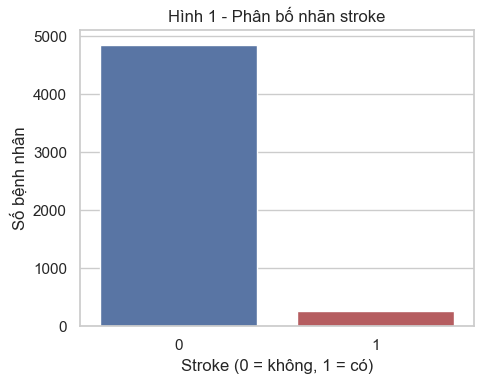

In [11]:
PROJECT_ROOT = next((root for root in [Path.cwd(), *Path.cwd().parents] if (root / 'docs').is_dir()), None)
FIGURES_DIR = PROJECT_ROOT / 'docs' / 'figures' if PROJECT_ROOT else Path('/content/docs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures output: {FIGURES_DIR}')

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='stroke', hue='stroke', palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('Hình 1 - Phân bố nhãn stroke')
plt.xlabel('Stroke (0 = không, 1 = có)')
plt.ylabel('Số bệnh nhân')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_target_distribution.png', dpi=120)
plt.show()

### Giải thích Hình 1

1. **Hình cho thấy gì?** Dữ liệu có 4.855 ca `stroke=0` (95,01%) và 255 ca `stroke=1` (4,99%).
2. **Ý nghĩa với bài toán?** Đây là bài toán phân loại nhị phân mất cân bằng; chỉ dùng Accuracy sẽ dễ che giấu việc bỏ sót ca dương tính.
3. **Quyết định xử lý tiếp theo:** Chia dữ liệu bằng `stratify`, dùng `class_weight='balanced'`, và ưu tiên Recall, Precision, F1 và ROC-AUC.

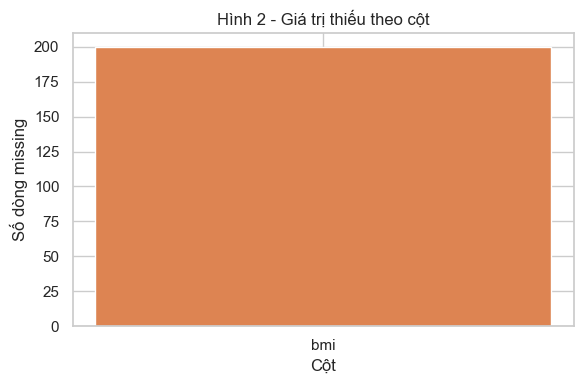

{'bmi': 200}


In [13]:
missing = df.isna().sum()
missing = missing[missing > 0]
plt.figure(figsize=(6, 4))
plt.bar(missing.index, missing.values, color='#DD8452')
plt.title('Hình 2 - Giá trị thiếu theo cột')
plt.xlabel('Cột')
plt.ylabel('Số dòng missing')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_missing_values.png', dpi=120)
plt.show()
print(missing.to_dict())

### Giải thích Hình 2

1. **Hình cho thấy gì?** Cột `bmi` có 200 giá trị thiếu trên 5.110 dòng, tương đương 3,91%; các cột còn lại không thiếu.
2. **Ý nghĩa với bài toán?** Xóa toàn bộ các dòng này sẽ làm mất dữ liệu, trong đó có thể có ca stroke hiếm.
3. **Quyết định xử lý tiếp theo:** Điền `bmi` bằng median được học trên tập train trong Pipeline, tránh rò rỉ dữ liệu.

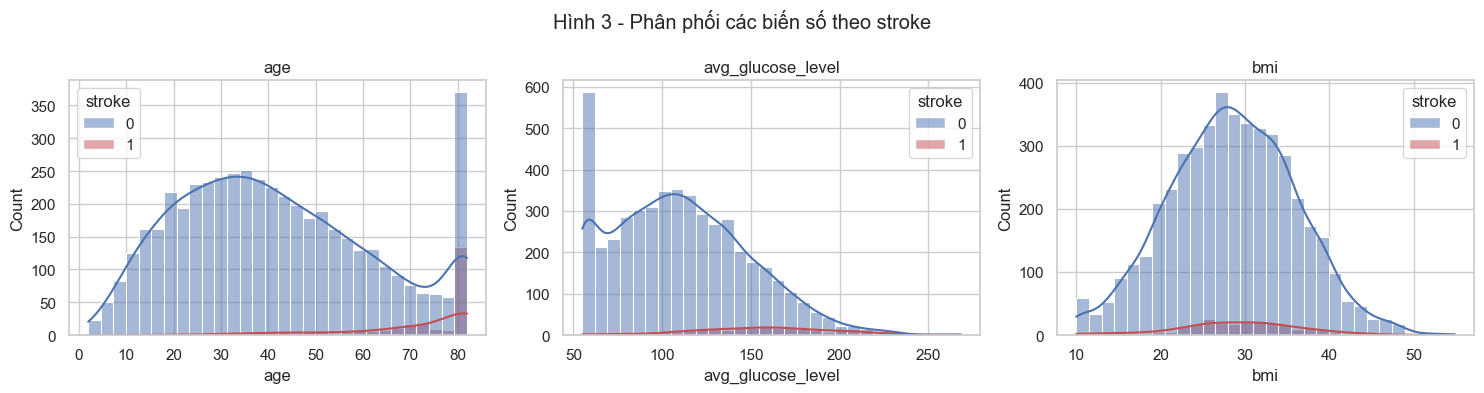

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ['age', 'avg_glucose_level', 'bmi']):
    sns.histplot(data=df, x=column, hue='stroke', bins=30, kde=True, ax=axis, palette=['#4C72B0', '#C44E52'])
    axis.set_title(column)
fig.suptitle('Hình 3 - Phân phối các biến số theo stroke')
fig.tight_layout()
plt.savefig(FIGURES_DIR / '03_numeric_distributions.png', dpi=120)
plt.show()

### Giải thích Hình 3

1. **Hình cho thấy gì?** `age`, `avg_glucose_level` và `bmi` có phân phối khác nhau giữa hai lớp; nhóm `stroke=1` có xu hướng tập trung ở tuổi và glucose cao hơn.
2. **Ý nghĩa với bài toán?** Các biến số có tín hiệu dự đoán, nhưng khác thang đo và có missing ở `bmi`.
3. **Quyết định xử lý tiếp theo:** Điền median cho biến số và dùng `StandardScaler` để các model tuyến tính/SVM không bị chi phối bởi thang đo.

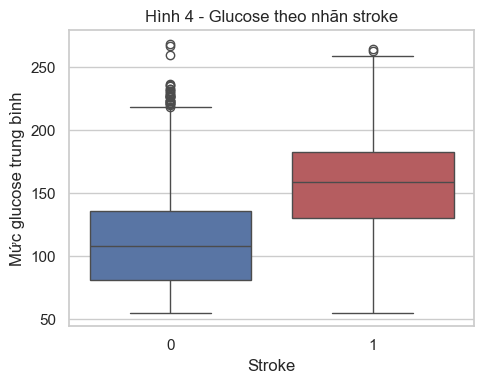

In [15]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=df, x='stroke', y='avg_glucose_level', hue='stroke', palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('Hình 4 - Glucose theo nhãn stroke')
plt.xlabel('Stroke')
plt.ylabel('Mức glucose trung bình')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_glucose_boxplot.png', dpi=120)
plt.show()

### Giải thích Hình 4

1. **Hình cho thấy gì?** Boxplot so sánh trung vị, khoảng tứ phân vị và các giá trị ngoại lai của glucose giữa `stroke=0` và `stroke=1`.
2. **Ý nghĩa với bài toán?** Glucose cao có thể giúp phân biệt nguy cơ, còn ngoại lai có thể là giá trị sức khỏe thật chứ không nhất thiết là lỗi.
3. **Quyết định xử lý tiếp theo:** Giữ ngoại lai, không cắt ngưỡng cơ học; để Pipeline chuẩn hóa và model học ảnh hưởng của biến này.

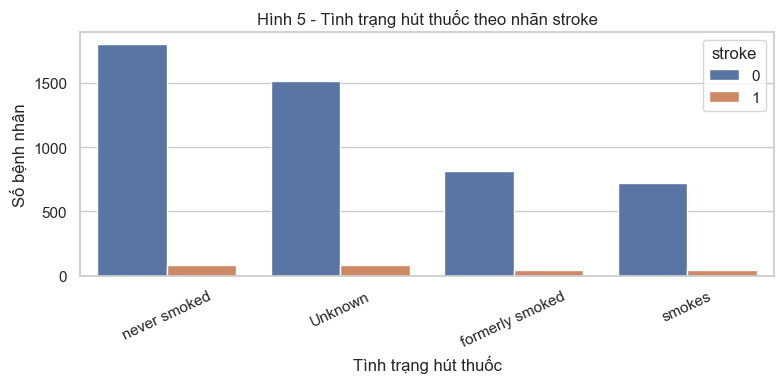

In [16]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='smoking_status', hue='stroke', order=df['smoking_status'].value_counts().index)
plt.title('Hình 5 - Tình trạng hút thuốc theo nhãn stroke')
plt.xlabel('Tình trạng hút thuốc')
plt.ylabel('Số bệnh nhân')
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_smoking_by_target.png', dpi=120)
plt.show()

### Giải thích Hình 5

1. **Hình cho thấy gì?** Biểu đồ tách số bệnh nhân theo các nhóm `smoking_status` và theo hai nhãn stroke; nhóm `Unknown` được giữ như một nhóm riêng.
2. **Ý nghĩa với bài toán?** Đây là biến phân loại, không có thứ tự số học tự nhiên; việc ép thành 0, 1, 2 sẽ tạo quan hệ giả.
3. **Quyết định xử lý tiếp theo:** Điền mode nếu có thiếu và mã hóa One-Hot với `handle_unknown='ignore'`.

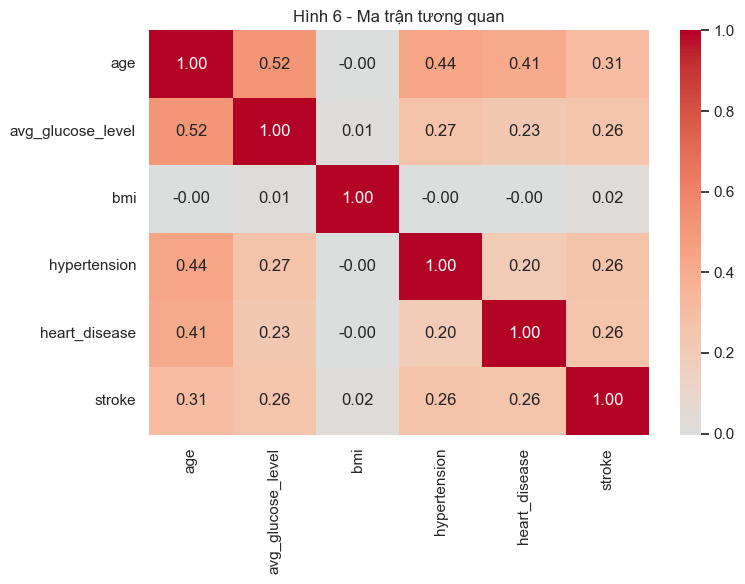

In [17]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Hình 6 - Ma trận tương quan')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_correlation_heatmap.png', dpi=120)
plt.show()

### Giải thích Hình 6

1. **Hình cho thấy gì?** Heatmap hiển thị hệ số tương quan giữa `age`, `avg_glucose_level`, `bmi`, bệnh nền và `stroke`; các hệ số được ghi trực tiếp trên hình.
2. **Ý nghĩa với bài toán?** Heatmap giúp nhận diện tín hiệu dự đoán và các cặp biến có thể trùng thông tin, nhưng tương quan không chứng minh quan hệ nhân quả.
3. **Quyết định xử lý tiếp theo:** Loại `id` vì chỉ là mã định danh; giữ các đặc trưng còn lại và dùng cross-validation để kiểm tra khả năng tổng quát.